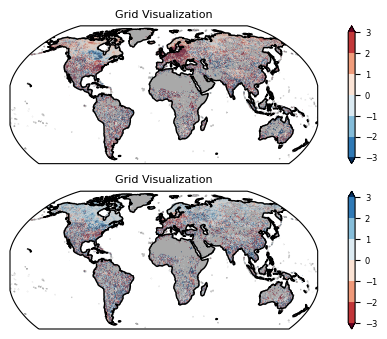

In [14]:
import sys
sys.path.append('../../my_spatial_analyze')
from visualization import plot_grid
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
sys.path.append('../../my_spatial_analyze/data_analyze/correlation_analysis')
import correlation_plots
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

grid_gdf_path = '/data/v2/grid_all_medium_for_extreme_changes.pkl'
grid_gdf = pd.read_pickle(grid_gdf_path)


ax_mosaic = """
    aaa
    bbb
"""

per_subplot_kw = {
    'a': {'projection': ccrs.Robinson()},
    'b': {'projection': ccrs.Robinson()},
}

fig, axs = plt.subplot_mosaic(
    ax_mosaic,
    figsize=(200/25.4, 100/25.4),
    per_subplot_kw=per_subplot_kw
)

grid_pkl_path = '/data/v2/grid_all_medium_for_extreme_changes.pkl'
grid_gdf = pd.read_pickle(grid_pkl_path)
_, sm_of_total_variation_percentage = plot_grid(
    grid_gdf=grid_gdf.copy().to_crs(ccrs.Robinson()),
    projection=ccrs.Robinson(),
    save_path=None,
    color_column='increases_in_low_water_extremes_count_median',
    gridlines=False,
    add_rivers=False,
    use_log_scale_color=False,
    set_global=False,
    extent=[-180, -60, 180, 90],
    use_discrete_color=True,
    discrete_bins=[-3, -2, -1, 0, 1, 2, 3],
    show=False,
    ax=axs['a'],
    draw_colorbar=True,
    return_colorbar_sm=True,
    cmap='RdBu_r',
    cbar_extend='both'
)

grid_pkl_path = '/data/v2/grid_all_medium_for_extreme_changes.pkl'
grid_gdf = pd.read_pickle(grid_pkl_path)
_, sm_of_total_variation_percentage = plot_grid(
    grid_gdf=grid_gdf.copy().to_crs(ccrs.Robinson()),
    projection=ccrs.Robinson(),
    save_path=None,
    color_column='increases_in_high_water_extremes_count_median',
    gridlines=False,
    add_rivers=False,
    use_log_scale_color=False,
    set_global=False,
    extent=[-180, -60, 180, 90],
    use_discrete_color=True,
    discrete_bins=[-3, -2, -1, 0, 1, 2, 3],
    show=False,
    ax=axs['b'],
    draw_colorbar=True,
    return_colorbar_sm=True,
    cmap='RdBu',
    cbar_extend='both'
)
# pdf
plt.savefig(
    '/results/Ext_Data_Fig_7_raw.pdf',
    bbox_inches='tight'
)
